In [1]:
library(openxlsx)

In [2]:
meta<-read.csv('1203-metavalid.csv',header=F)

In [3]:
meta

V1,V2,V3
<chr>,<chr>,<chr>
PUMCH217,陈云,AL
PUMCH003,解统珍,AL
PUMCH020,仲美英,AL
PUMCH131,苗运付,AL
PUMCH138,张秀芳,AL
PUMCH140,张启富,AL
PUMCH141,赵明东,AL
PUMCH144,张宝臣,AL
PUMCH150,王洪生,AL


In [4]:
meta2<-meta
colnames(meta2)<-c('ID','name','type')

In [5]:
#database,csv,xls,xlsx

In [6]:
filenames <- dir()
# 通过正则，获取所有xlsx结尾的文件名
filedb <- grep('\\.database', filenames, value = TRUE)
filecsv <- grep('\\.csv', filenames, value = TRUE)
filexls <- grep('\\.xls', filenames, value = TRUE)

In [7]:
table(meta2$type)


   AL  MGUS    MM POEMS 
  134    20   212    67 

In [8]:
filedbvalid<-intersect(filedb,paste(meta2$ID,'.database',sep=""))

In [9]:
filecsvvalid<-intersect(filecsv,paste(meta2$ID,'.csv',sep=""))

In [10]:
filexlsvalid<-intersect(filexls,paste(meta2$ID,'.xls',sep=""))

In [11]:
length(filedbvalid)
length(filecsvvalid)
length(filexlsvalid)

[1] 149

[1] 88

[1] 133

In [12]:
allin<-c(gsub('.database','',filedbvalid),gsub('.csv','',filecsvvalid),gsub('.xls','',filexlsvalid))

In [13]:
rownames(meta2)<-meta2$ID

In [14]:
meta3<-meta2[allin,]

In [15]:
meta3<-meta3[,-2]

In [16]:
table(meta3$type)


   AL  MGUS    MM POEMS 
  126    13   165    66 

[1].database integration

In [17]:
db<-read.table(filedbvalid[1],sep='\t')
colnames(db)<-db[1,]
db<-db[-1,]
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','MutationRate')]

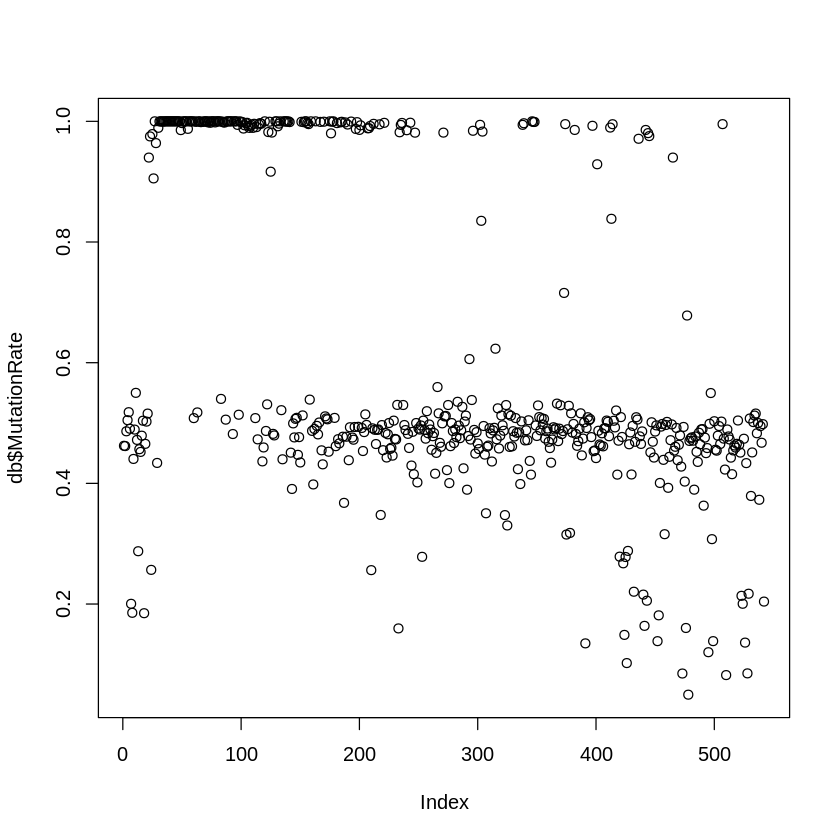

In [18]:
plot(db$MutationRate)

In [19]:
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$MutationRate<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")

In [20]:
df<-data.frame(db[,11],1)

In [21]:
colnames(df)<-c('feature',filedbvalid[1])

In [22]:
length(filedbvalid)

[1] 149

In [23]:
for (i in 2:149){
db<-read.table(filedbvalid[i],sep='\t')
colnames(db)<-db[1,]
db<-db[-1,]
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','MutationRate')]
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$MutationRate<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")
db<-data.frame(db[,11],1)
colnames(db)<-c('feature',filedbvalid[i])
df<-merge(df,db,all=T)
    }

In [24]:
dim(df)

[1] 2710  150

In [25]:
df[is.na(df)]<-0

In [26]:
filedballin<-df

[2].csv integration

In [27]:
db<-read.csv(filecsvvalid[1])
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','MutationRate')]

In [28]:
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$MutationRate<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")

In [29]:
df<-data.frame(db[,11],1)

In [30]:
colnames(df)<-c('feature',filecsvvalid[1])

In [31]:
length(filecsvvalid)

[1] 88

In [32]:
for (i in 2:88){
db<-read.csv(filecsvvalid[i])
colnames(db)<-gsub('Mutation.ratio','MutationRate',colnames(db))
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','MutationRate')]
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$MutationRate<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")
db<-data.frame(db[,11],1)
colnames(db)<-c('feature',filecsvvalid[i])
df<-merge(df,db,all=T)
    print(i)
    }

[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10
[1] 11
[1] 12
[1] 13
[1] 14
[1] 15
[1] 16
[1] 17
[1] 18
[1] 19
[1] 20
[1] 21
[1] 22
[1] 23
[1] 24
[1] 25
[1] 26
[1] 27
[1] 28
[1] 29
[1] 30
[1] 31
[1] 32
[1] 33
[1] 34
[1] 35
[1] 36
[1] 37
[1] 38
[1] 39
[1] 40
[1] 41
[1] 42
[1] 43
[1] 44
[1] 45
[1] 46
[1] 47
[1] 48
[1] 49
[1] 50
[1] 51
[1] 52
[1] 53
[1] 54
[1] 55
[1] 56
[1] 57
[1] 58
[1] 59
[1] 60
[1] 61
[1] 62
[1] 63
[1] 64
[1] 65
[1] 66
[1] 67
[1] 68
[1] 69
[1] 70
[1] 71
[1] 72
[1] 73
[1] 74
[1] 75
[1] 76
[1] 77
[1] 78
[1] 79
[1] 80
[1] 81
[1] 82
[1] 83
[1] 84
[1] 85
[1] 86
[1] 87
[1] 88


In [33]:
dim(df)

[1] 2179   89

In [34]:
df[is.na(df)]<-0

In [35]:
filecsvallin<-df

[3] .xls integration

In [36]:
db<-read.table(filexlsvalid[1],sep='\t')
colnames(db)<-db[1,]
db<-db[-1,]
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','Mutation.ratio')]

In [37]:
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$Mutation.ratio<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")

In [38]:
df<-data.frame(db[,11],1)

In [39]:
colnames(df)<-c('feature',filexlsvalid[1])

In [40]:
length(filexlsvalid)

[1] 133

In [41]:
for (i in 2:133){
db<-read.table(filexlsvalid[i],sep='\t')
colnames(db)<-db[1,]
db<-db[-1,]
db<-db[,c('Chr','Start','End','Ref','Alt','Func.refGene','Gene.refGene','ExonicFunc.refGene','SIFT_pred','Mutation.ratio')]
db<-db[which(db$Func.refGene=='exonic'),]
db<-db[which(db$ExonicFunc.refGene=='nonsynonymous SNV'),]
db<-db[which(db$SIFT_pred=='D'),]
db<-db[which(db$Mutation.ratio<0.5),]
db$feature<-paste(db$Chr,db$Start,db$End,db$Ref,db$Alt,db$Gene.refGene,sep="_")
db<-data.frame(db[,11],1)
colnames(db)<-c('feature',filexlsvalid[i])
df<-merge(df,db,all=T)
    print(i)
    }

[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10
[1] 11
[1] 12
[1] 13
[1] 14
[1] 15
[1] 16
[1] 17
[1] 18
[1] 19
[1] 20
[1] 21
[1] 22
[1] 23
[1] 24
[1] 25
[1] 26
[1] 27
[1] 28
[1] 29
[1] 30
[1] 31
[1] 32
[1] 33
[1] 34
[1] 35
[1] 36
[1] 37
[1] 38
[1] 39
[1] 40
[1] 41
[1] 42
[1] 43
[1] 44
[1] 45
[1] 46
[1] 47
[1] 48
[1] 49
[1] 50
[1] 51
[1] 52
[1] 53
[1] 54
[1] 55
[1] 56
[1] 57
[1] 58
[1] 59
[1] 60
[1] 61
[1] 62
[1] 63
[1] 64
[1] 65
[1] 66
[1] 67
[1] 68
[1] 69
[1] 70
[1] 71
[1] 72
[1] 73
[1] 74
[1] 75
[1] 76
[1] 77
[1] 78
[1] 79
[1] 80
[1] 81
[1] 82
[1] 83
[1] 84
[1] 85
[1] 86
[1] 87
[1] 88
[1] 89
[1] 90
[1] 91
[1] 92
[1] 93
[1] 94
[1] 95
[1] 96
[1] 97
[1] 98
[1] 99
[1] 100
[1] 101
[1] 102
[1] 103
[1] 104
[1] 105
[1] 106
[1] 107
[1] 108
[1] 109
[1] 110
[1] 111
[1] 112
[1] 113
[1] 114
[1] 115
[1] 116
[1] 117
[1] 118
[1] 119
[1] 120
[1] 121
[1] 122
[1] 123
[1] 124
[1] 125
[1] 126
[1] 127
[1] 128
[1] 129
[1] 130
[1] 131
[1] 132
[1] 133


In [42]:
dim(df)

[1] 1573  134

In [43]:
df[is.na(df)]<-0

In [44]:
filexlsallin<-df

In [45]:
dim(filedballin)
dim(filecsvallin)
dim(filexlsallin)

[1] 2710  150

[1] 2179   89

[1] 1573  134

In [46]:
dbcsv<-merge(filedballin,filecsvallin,all=T)
dbcsvxls<-merge(dbcsv, filexlsallin,all=T)
dim(dbcsvxls)

[1] 5572  371

In [47]:
dbcsvxls[is.na(dbcsvxls)]<-0

In [48]:
colnames(dbcsvxls)<-gsub('.database','',colnames(dbcsvxls))
colnames(dbcsvxls)<-gsub('.xls','',colnames(dbcsvxls))
colnames(dbcsvxls)<-gsub('.csv','',colnames(dbcsvxls))

In [49]:
dbcsvxls

feature,PUMCH001,PUMCH002,PUMCH003,PUMCH004,PUMCH010,PUMCH012,PUMCH013,PUMCH014,PUMCH015,⋯,WUHAN51,WUHAN52,WUHAN53,WUHAN54,WUHAN55,WUHAN56,WUHAN57,WUHAN58,WUHAN59,WUHAN60
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_114713907_114713907_T_G_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_114713908_114713908_T_C_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_114713909_114713909_G_T_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_114716124_114716124_C_G_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_115256528_115256528_T_A_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_115256528_115256528_T_G_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_115256529_115256529_T_A_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1_115256529_115256529_T_C_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,0
chr1_115256530_115256530_G_T_NRAS,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [50]:
dbcsvxls$X<-NULL

In [51]:
for (i in 2:371){
dbcsvxls[,i]<-as.numeric(as.character(dbcsvxls[,i]))}

In [52]:
write.csv(dbcsvxls,'0103-dbcsvxls.csv')

dense to gene

In [53]:
library(tidyr)
data1 <- separate(dbcsvxls,feature, into= c('Chr','Start','End','Ref','Alt','Gene.refGene'),sep= "_")

In [54]:
data1

Chr,Start,End,Ref,Alt,Gene.refGene,PUMCH001,PUMCH002,PUMCH003,PUMCH004,⋯,WUHAN51,WUHAN52,WUHAN53,WUHAN54,WUHAN55,WUHAN56,WUHAN57,WUHAN58,WUHAN59,WUHAN60
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1,114713907,114713907,T,G,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,114713908,114713908,T,C,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,114713909,114713909,G,T,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,114716124,114716124,C,G,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,115256528,115256528,T,A,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,115256528,115256528,T,G,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,115256529,115256529,T,A,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1,115256529,115256529,T,C,NRAS,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,0
chr1,115256530,115256530,G,T,NRAS,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [55]:
data1<-data1[,6:376]

In [56]:
library(dplyr)
expr_df<-data1 %>% group_by(Gene.refGene) %>% summarise_each(funs(sum)) 
expr_df<-as.data.frame(expr_df)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“`summarise_each_()` was deprecated in dplyr 0.7.0.
Please use `across()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_warnings()` to see where this warning was generated.”
Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
Please use a list of either functions or lambdas: 

  # Simple named list: 
  list(mean = mean, median = median)

  # Auto named with `tibble::lst()`: 
  tibble::lst(mean, median)

  # Using lambdas
  list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))
This warning is displayed once every 8 hours.
Call `lifecycle::last_warnings()` to see where this warning was generated.”


In [57]:
dim(expr_df)
dim(data1)

[1] 370 371

[1] 5572  371

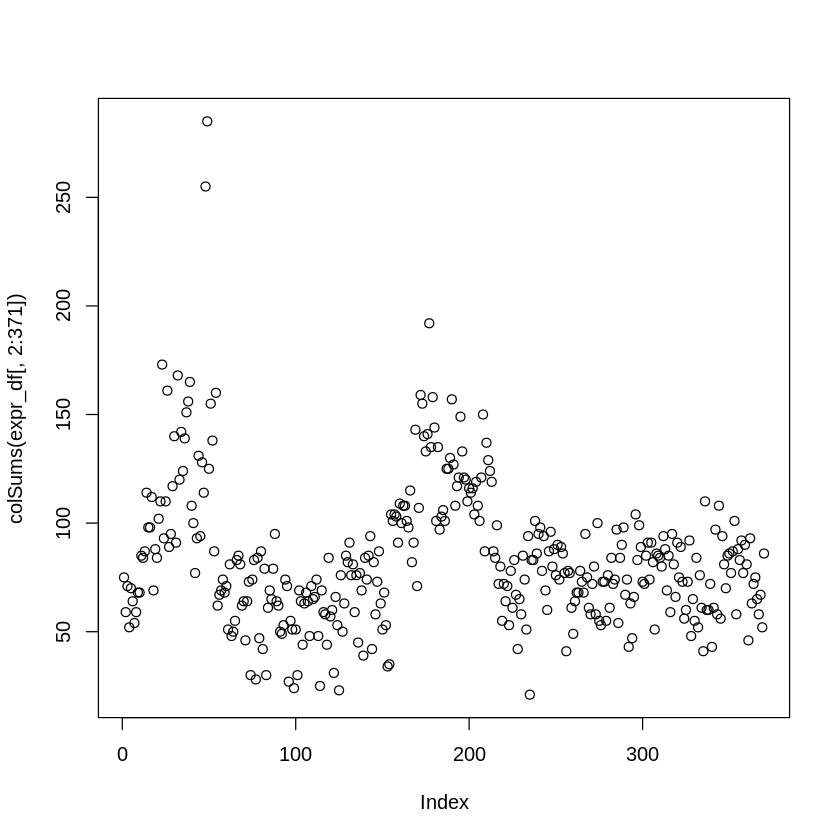

In [58]:
plot(colSums(expr_df[,2:371]))

In [60]:
expr_df$PUMCH143<-NULL
expr_df$PUMCH144<-NULL
expr_df$WUHAN41<-NULL

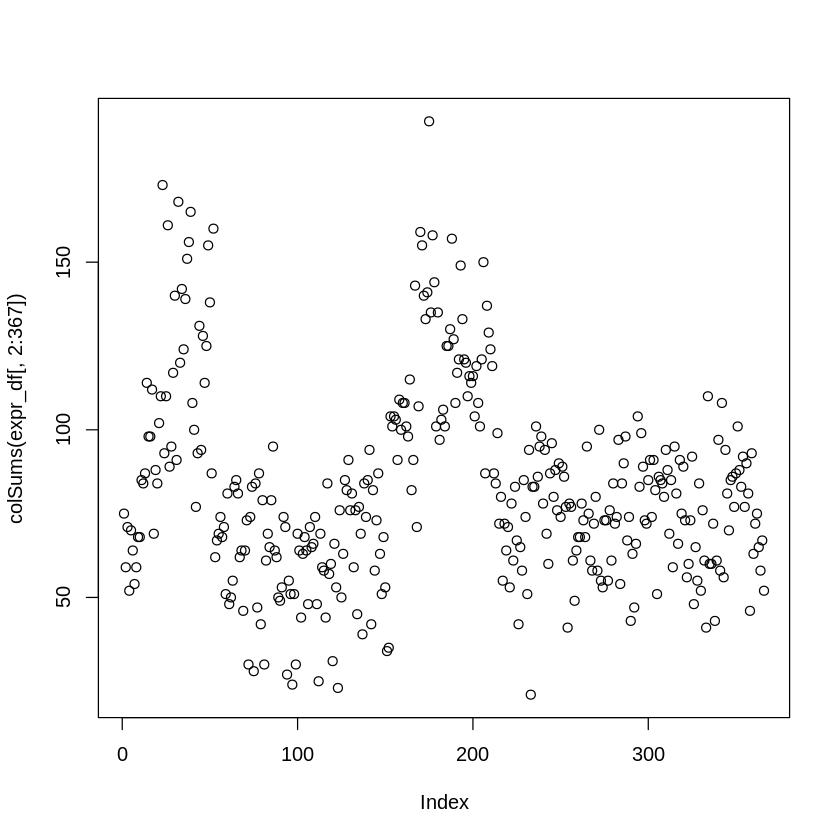

In [61]:
plot(colSums(expr_df[,2:367]))

In [62]:
write.csv(expr_df,'0103-dbcsvxlswithnormaldensebygene.csv')